### 1. Import Library

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

### 2. Load Dataset

In [22]:
df = pd.read_excel('../data/worldcities.xlsx')
df.head()

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629


### 3. Preprocess Data

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48059 entries, 0 to 48058
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        48059 non-null  object 
 1   city_ascii  48057 non-null  object 
 2   lat         48059 non-null  float64
 3   lng         48059 non-null  float64
 4   country     48059 non-null  object 
 5   iso2        48026 non-null  object 
 6   iso3        48059 non-null  object 
 7   admin_name  47858 non-null  object 
 8   capital     15138 non-null  object 
 9   population  47808 non-null  float64
 10  id          48059 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 4.0+ MB


cek missing value

In [24]:
df.isnull().sum()

city              0
city_ascii        2
lat               0
lng               0
country           0
iso2             33
iso3              0
admin_name      201
capital       32921
population      251
id                0
dtype: int64

mengatasi missing value

In [ ]:
df['city_ascii'] = df['city_ascii'].fillna(df['city'])
df['iso2'] = df['iso2'].fillna("Unknown")
df['admin_name'] = df['admin_name'].fillna("Unknown")
df['capital'] = df['capital'].fillna("Unknown")
df['population'] = df['population'].fillna(0)   # data demografi tidak dipakai

cek kembali missing value

In [26]:
df.isnull().sum()

city          0
city_ascii    0
lat           0
lng           0
country       0
iso2          0
iso3          0
admin_name    0
capital       0
population    0
id            0
dtype: int64

### 4. Filter dataset untuk Indonesia saja

In [27]:
df_id = df[df['country'] == "Indonesia"].copy()
df_id.head()

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
78,Surabaya,Surabaya,-7.2458,112.7378,Indonesia,ID,IDN,Jawa Timur,admin,6556000.0,1360484663
207,Medan,Medan,3.5894,98.6739,Indonesia,ID,IDN,Sumatera Utara,admin,3632000.0,1360543171
286,Malang,Malang,-7.9800,112.6200,Indonesia,ID,IDN,Jawa Timur,Unknown,2795209.0,1360141408
349,Bekasi,Bekasi,-6.2333,107.0000,Indonesia,ID,IDN,Jawa Barat,Unknown,2381053.0,1360673840


### 5. Ambil koordinat lat & lng

In [28]:
coords = df_id[['lat', 'lng']].values

### 6. Normalisasi koordinat

In [29]:
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

### 7. Jalankan DBSCAN

In [30]:
db = DBSCAN(eps=0.25, min_samples=5)
labels = db.fit_predict(coords_scaled)
df_id['cluster'] = labels

### 8. Lihat hasil cluster

In [31]:
df_id['cluster'].value_counts()

cluster
 0    152
 1     48
-1     32
 2     21
 5     20
 3      7
 4      6
 7      6
 6      5
Name: count, dtype: int64

### 9. Visualisasi Hasil Cluster

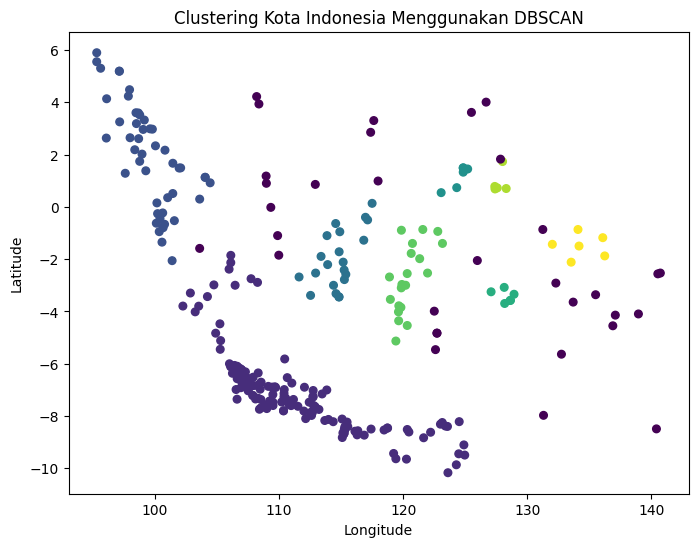

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(df_id['lng'], df_id['lat'], c=df_id['cluster'], s=30)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clustering Kota Indonesia Menggunakan DBSCAN")
plt.show()